Say you've been iterating on a prompt for a **support ticket classifier**: a backend system that routes incoming customer requests into one of four queues: `BILLING`, `TECHNICAL`, `ACCOUNT`, or `GENERAL`. This system needs to run fast, so you're hoping to run it on a very small local model, `gemma3:1b`. 

You've tried eight different prompt template variations: a zero-shot baseline, a role-framed variant, one with explicit category definitions, two few-shot variants (1-example and 3-example), a chain-of-thought approach, one that returns JSON, and one with negative framing ("do *not* confuse BILLING with ACCOUNT").

After running the eval on 20 labeled examples with a local Ollama model (`gemma3:1b`), you compute mean accuracy per prompt in the hopes of finding the "winner":

P0_baseline                   45.0%
P1_role                       50.0%
P2_definitions                40.0%
P3_few_shot_1                 40.0%
P4_few_shot_3                 45.0%
P5_chain_of_thought           45.0%
P6_json_output                55.0%
P7_negative_framing           25.0%


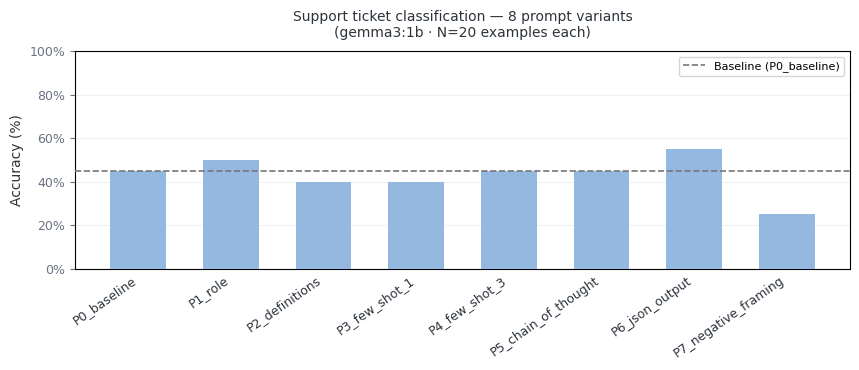

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import promptstats as pstats
pstats.set_alpha_ci(0.05)  # Use 95% CIs throughout this notebook (package default is 99%)

# Load eval results.
# Columns: prompt_id, input_id, ticket, category, output, predicted, correct
df = pd.read_csv("support_ticket_eval_20.csv")
def get_scores_from_df(df):
    return {
        p: df[df["prompt_id"] == p]["correct"].tolist()
        for p in PROMPTS
    }

# The CSV stores expected/predicted pairs (not precomputed scores),
# so we compute per-prompt accuracy manually from `correct`.
PROMPTS = df["prompt_id"].dropna().drop_duplicates().tolist()

# Mean accuracy per prompt
scores = get_scores_from_df(df)
summary = {p: round(sum(v) / len(v) * 100, 1) for p, v in scores.items()}
for p, acc in summary.items():
    print(f"{p:<28}  {acc:.1f}%")

pstats.plot_accuracy_bar(
    scores,
    baseline="P0_baseline",
    title=(
        "Support ticket classification — 8 prompt variants\n"
        "(gemma3:1b · N=20 examples each)"
    ),
)
plt.show()

Look definitive? `P6_json_output` and `P1_role` are clear winners, right?

Well, maybe it was just chance. Let's estimate 95% confidence intervals as error bars, and see how that pans out:

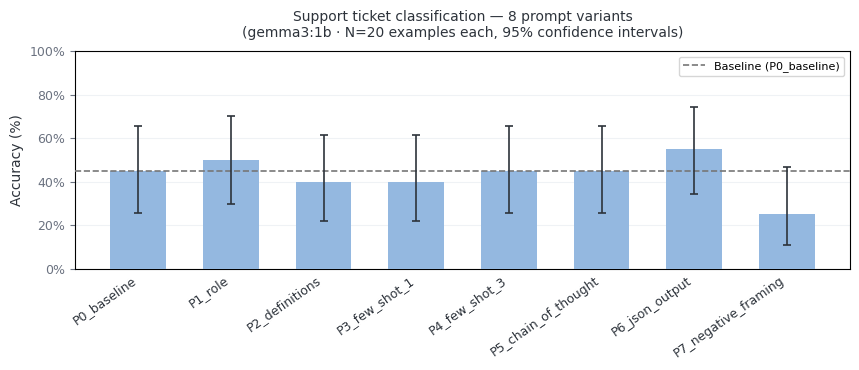

In [2]:
report = pstats.compare_prompts(
    scores,
    simultaneous_ci=True, # This is true by default, but we set it explicitly here for clarity.
    rng=np.random.default_rng(42),
)

report.plot_bars(
    baseline="P0_baseline",
    title=(
        "Support ticket classification — 8 prompt variants\n"
        "(gemma3:1b · N=20 examples each, 95% confidence intervals)"
    ),
)
plt.show()

**Uh-oh!**

The error bars have revealed a severe problem—we can't conclude almost anything at all from this analysis. All error bars overlap, meaning our "conclusions" on top performers could just be random chance.

So, to address this problem, let's double the size of our eval set. With more data should come more certainty, right? Right?

## Expanding our eval set to N=40 samples

Now we add more examples (equally for each of 4 classifications), and arrive at a set with N=40 samples. Let's re-run the analysis:

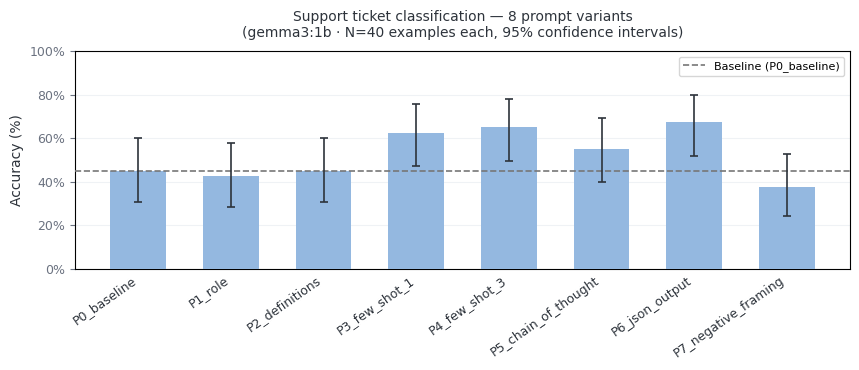

In [3]:
df = pd.read_csv("support_ticket_eval_40.csv")
scores = get_scores_from_df(df)

report = pstats.compare_prompts(
    scores,
    rng=np.random.default_rng(42),
)

report.plot_bars(
    baseline="P0_baseline",
    title=(
        "Support ticket classification — 8 prompt variants\n"
        "(gemma3:1b · N=40 examples each, 95% confidence intervals)"
    ),
)
plt.show()

A little clearer, perhaps. The early performance of `P1_role` seems like a fluke, while `P3_few_shot_1` is much better. But still considerable overlap in error bars. At this point, we might hold our head in our hands and sigh—if even N=40 samples isn't enough to detect a clear difference, what are we even doing? Should we just give up on stats if it means we need benchmark-size eval sets?

**But wait, is this really the kind of comparison we should be doing?**

## Pairwise comparisons

We've been plotting the score distribution of each prompt, independently. However, these aren't independent samples! Each prompt was run on the exact same inputs. That means we can exploit the correlated samples to increase our statistically power—basically, the effective "error bars" are _actually_ likely narrower than our bar chart admits. 

So what we really want are _pairwise_ comparisons. Pairwise means we compare prompts example by example rather than treating each prompt’s accuracy as if it came from a separate experiment. For each shared input, we ask: did prompt A get this one right when prompt B got it wrong? Basically, for each pair, we make a table like this:

| Input | Prompt A | Prompt B | A − B |
|------:|:-:|:-:|:-----:|
| 1     | 1 | 0 | +1    |
| 2     | 0 | 0 | 0     |
| 3     | 1 | 1 | 0     |
| 4     | 0 | 1 | −1    |
| ...   | ... | ... | ... |
| N     | 1 | 0 | +1    |

and compute the _mean difference_ and 95% CI around this point estimate.

And we do that for every combination of prompts. That removes a lot of the noise coming from item difficulty. Easy items are easy for everyone, hard items are hard for everyone, and the analysis can focus on the actual differences between prompts.

With 8 prompts, there's $\frac{n(n-1)}{2}=\frac{8 \times 7}{2}=28$ pairwise comparisons. That's kind of a lot, but, let's just compute 95% CIs for each one, and then check which CIs are—

## The multiple comparisons problem

CIs, like p-values, suffer from false positives. When performing multiple independent comparisons, the probability of encountering at least one false positive increases significantly beyond the original error rate of a single test. This phenomenon is known as the **Family-Wise Error Rate (FWER)**, and it's so common that [even XKCD made fun of it](https://xkcd.com/882/).

To be precise here, let's the probability of a false positive. Since we have a 95% Confidence Interval for each comparison, our risk of a false positive for any _single_ test is $5\%$ ($\alpha = 0.05$). To find the probability of at least one error across **28 comparisons**, we first calculate the probability of all 28 being "correct" (no false positives) and subtract that from 1:

1.  Probability of no error in one test: $1 - 0.05 = 0.95$
2.  Probability of no errors in 28 tests: $0.95^{28} \approx 0.2378$
3.  Probability of at least one false positive: $1 - 0.2378 = 0.7622$

Thus, there is a **76.2% chance** (!!) that at least one of those 28 comparisons will result be a fluke (purely due to random noise). And if we extend this analysis, we'll see it's about a 41% chance for at least _two_ flukes.

Crap.

## Multiple comparisons correction with simultaneous CIs

The standard fix is to require that your **confidence intervals** account for the full family of comparisons, not just each pair in isolation.

`promptstats` does this with **simultaneous confidence intervals**, which it applies by default. A marginal 95% CI for a single comparison means that one interval covers the true difference 95% of the time. A *simultaneous* 95% CI family means that 95% of the time, *all* intervals — across every pairwise comparison — cover their true differences at once. This stricter guarantee controls for the family-wise error rate, and it's the CI analogue to p-value methods like Bonferroni-Holm.

In practice, simultaneous CIs are wider than marginal ones. The more comparisons you run, the wider they become. The interpretation is direct: **if a simultaneous pairwise CI excludes zero, the difference is confirmed**; if it straddles zero, the two prompts are indistinguishable at your chosen confidence level. 

> By default, `promptstats` uses the **bootstrap max-T method** to compute simultaneous CIs—which is less conservative than Bonferroni when comparisons are correlated (as they typically are when all prompts share similar structure or we run against the same model). It also computes p-values from these intervals, for those who want them. For non-bootstrap methods like `Newcombe` and `bayes_binary` (chosen automatically for binary data at small N), `prompstats` falls back to Bonferroni for adjusting the p-values. Either way, `simultaneous_ci=True` is default and corrects for FWER.

Let's run the full analysis:

  Prompt                   Mean  95% CI                  Status
  -----------------------------------------------------------------
  P6_json_output         67.5%  [52.0%, 79.9%]          in contention
  P4_few_shot_3          65.0%  [49.5%, 77.9%]          in contention
  P3_few_shot_1          62.5%  [47.0%, 75.8%]          in contention
  P5_chain_of_thought    55.0%  [39.8%, 69.3%]          in contention
  P0_baseline            45.0%  [30.7%, 60.2%]          in contention
  P2_definitions         45.0%  [30.7%, 60.2%]          outperformed
  P1_role                42.5%  [28.5%, 57.8%]          outperformed
  P7_negative_framing    37.5%  [24.2%, 53.0%]          outperformed


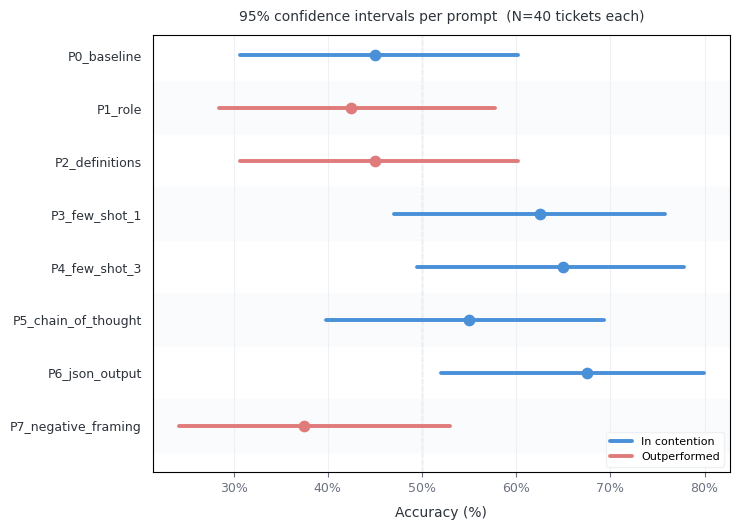

In [4]:
# One score array per prompt (40 binary values each)
scores = {
    p: df[df["prompt_id"] == p]["correct"].tolist()
    for p in PROMPTS
}

# simultaneous_ci=True (default): pairwise CIs are widened to control FWER.
# Tiers and forest plot colors are derived from CI-bound significance,
# keeping them consistent with the displayed intervals.
report = pstats.compare_prompts(
    scores,
    simultaneous_ci=True, # This is true by default, but we set it explicitly here for clarity.
    rng=np.random.default_rng(42),
)

report.print_ci_table(sort_by="mean")

pstats.plot_ci_forest(
    report,
    title="95% confidence intervals per prompt  (N=40 tickets each)",
    sort_by="input_order"
)
plt.show()

In [5]:
report.summary(pairwise_sort="significance")

 PROMPTS COMPARISON 
8 prompts | 40 inputs | method=bayes_binary | 95% confidence intervals (CI)

--- Mean Advantage (Wilson CIs) ---
  axis: [-0.625, +0.625]  (· spread, ─ CI, ● mean, │ grand mean)  spread percentiles = (10, 90)
  Prompt                   Interval Plot                                 Mean    CI Low   CI High  Spread Lo  Spread Hi
  P0_baseline              ·············─────●─│──··········           0.450    0.307    0.602    -0.100     0.913
  P1_role                  ············─────●──│──··                   0.425    0.285    0.578    -0.100     0.663
  P2_definitions               ·········─────●─│──··········           0.450    0.307    0.602     0.013     0.900
  P3_few_shot_1                            ··──│──●────·····           0.625    0.470    0.758     0.400     0.900
  P4_few_shot_3                            ···─│───●────········       0.650    0.495    0.779     0.400     1.025
  P5_chain_of_thought              ········────│●────·······           0.55

## Reading the results

The executive summary groups prompts into **tiers** based on which simultaneous pairwise CIs exclude zero — i.e., which pairs can be distinguished despite the full family of comparisons.

**Group #1 (tied at the top):** `P6_json_output`, `P4_few_shot_3`, `P3_few_shot_1`, `P5_chain_of_thought`, `P0_baseline`. These five prompts — spanning raw accuracies from **45.0% to 67.5%** — are statistically *indistinguishable* from one another at N=40. Every simultaneous pairwise CI within this group straddles zero: no gap is large enough to distinguish from noise.

**Group #2 (confirmed underperformers):** `P2_definitions` (45.0%), `P1_role` (42.5%), and `P7_negative_framing` (37.5%) are significantly *worse* than the top tier. Their simultaneous pairwise difference CIs versus P6 all exclude zero. This is the most actionable finding: three common prompt patterns genuinely hurt performance on this model. A definition-heavy prompt, a role-only persona with no other guidance, and negative/contrastive framing ("do NOT confuse BILLING with ACCOUNT") all backfire on this model.

> **Why do some CIs appear "outperformed" (red) even when they visually overlap with blue ones?** The forest plot shows **per-prompt accuracy CIs** — one interval per prompt, asking "where does this prompt's true accuracy lie?" The tier colors come from **pairwise difference CIs**, which ask "does the CI for prompt A minus prompt B exclude zero?" These are different objects. Per-prompt CIs can visually overlap while the pairwise difference CI still excludes zero, because the shared test set gives you more precision on the *difference* than a naive comparison of individual intervals suggests. If two CIs look overlapping but one is red, look at the Pairwise Comparisons section to see the actual difference CI.

**What happened to the "winner"?** `P6_json_output` at 67.5% looked like a clear leader. But the simultaneous 95% CI on its pairwise *difference* versus `P0_baseline` straddles zero — the 22-point gap is not distinguishable from sampling noise. With N=40, you simply don't have the resolution. To reliably detect a 20-point gap at 80% power, you'd need roughly **N=80–100 tickets**. To detect a 10-point gap, closer to **N=250+**.

The raw bar chart told a story. A lot of it was noise.

> **Honest reporting template.** *"Among the five top-tier prompts, differences are within sampling noise at N=40. `P6_json_output` has the highest point estimate (67.5%) and is a reasonable provisional choice, but the margin over baseline is not statistically confirmed. `P1_role`, `P2_definitions`, and `P7_negative_framing` are confirmed underperformers and should be dropped. Re-run the eval with ~150 tickets to resolve the top-tier ranking."*

## Critical difference diagrams
The "statistically indistinguishable rank bands" computed in the pairwise output is effectively the same information for a [critical difference diagram](https://mirkobunse.github.io/CriticalDifferenceDiagrams.jl/dev/), introduced by Janez Demšar in the famous ML paper, [Statistical Comparisons of Classifiers over Multiple Data Sets](https://www.jmlr.org/papers/volume7/demsar06a/demsar06a.pdf). You can use `promptstats` to plot that diagram, if you'd like:

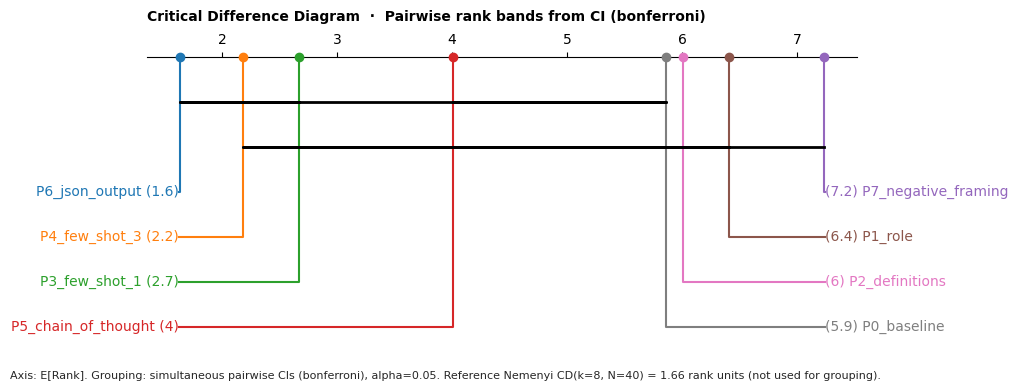

In [6]:
pstats.plot_critical_difference(report)
plt.show()

Notice the rank banks are the same as the "statistically indistinguishable rank bands" output in the Pairwise Comparisons section: we have five leaders that can't be distinguished from one another, followed by a group of 7 (the rest), but you'll notice a big overlap—this is normal, even if it's non-intuitive. It means that we can't say the elements of that rank band are significantly different from one another, statistically speaking. 

So, in this diagram, what is clear is that P6 is doing very well and clearly better than P2, P1, and P7. Yet, it's too early to say just _how_ well.

> **What do the numbers mean?**: Here we've done something fancy—to be consistent with our estimation-based statistics philosophy that emphasizes CIs and resampling rather than p-values, we've used E[rank], which uses bootstrap resampling to estimate rank probabilities per each prompt. In Demsar's initial paper, you compute these values from the Friedman test. However, the Friedman test is an omnibus test used in a null-hypothesis testing framework—that's inconsistent with our philosophy here and it's also inconsistent with the way we computed the rank bands, which used simultaneous CIs rather than the p-values. Thus, here `promptstats` is doing the "estimation statistics" equivalent of CD diagrams. By the way, if you had set `omnibus=True`, `promptstats` would have used the Friedman test information instead. 

## Expanding the eval set — and adding multiple runs

Our CIs were wide for two reasons: only 40 tickets, and possible run-to-run stochasticity at
temperature > 0. We tackle both at once.

We rebuilt the eval set with **120 tickets** (30 per category): the original 10 clear-cut
examples per category, 10 harder **boundary cases** that straddle two categories, and 10
**adversarial cases** that use surface framing designed to mislead simpler prompts. For example:

| Ticket | Looks like | Actually |
|--------|-----------|---------|
| "The feature I upgraded for last month never worked — I'd like a credit." | TECHNICAL | **BILLING** |
| "2FA codes never arrive by SMS, no matter how many retries." | ACCOUNT | **TECHNICAL** |
| "What's the difference between Owner, Admin, and Member roles?" | ACCOUNT | **GENERAL** |
| "After rotating my API key, all production integrations broke." | ACCOUNT | **TECHNICAL** |
| "You charged me twice and your team keeps closing my ticket without fixing it." | BILLING | **GENERAL** |

We also ran each (prompt, ticket) pair **5 times** at temperature=1.0. Passing a `(M=120, R=5)`
score matrix per prompt activates the *nested bootstrap* — resampling both tickets and runs within
each ticket — so CIs reflect both sources of variance.

The question: **which lever actually moved the needle?**

Let's start by checking run-to-run consistency on the expanded set:

In [7]:
# Load the multi-run CSV (one row per prompt x ticket x run)
df_mr = pd.read_csv("support_ticket_eval_multirun.csv")

# Accuracy per (prompt, run) — if scores are flat across runs,
# run-to-run variance is low and extra runs won't tighten CIs much
run_acc = (
    df_mr.groupby(["prompt_id", "run_idx"])["correct"]
    .mean()
    .unstack("run_idx")
    .loc[PROMPTS]
)
run_acc.columns = [f"run {c}" for c in run_acc.columns]
run_acc["mean"] = run_acc.mean(axis=1)
run_acc["std"]  = run_acc.iloc[:, :5].std(axis=1)

print("Per-run accuracy (temperature=1.0, 5 runs x 120 tickets):")
print(run_acc.to_string(float_format="{:.1%}".format))

Per-run accuracy (temperature=1.0, 5 runs x 120 tickets):
                     run 1  run 2  run 3  run 4  run 5  mean  std
prompt_id                                                        
P0_baseline          42.5%  45.8%  44.2%  44.2%  44.2% 44.2% 1.2%
P1_role              40.8%  40.0%  44.2%  40.8%  42.5% 41.7% 1.7%
P2_definitions       38.3%  38.3%  38.3%  39.2%  38.3% 38.5% 0.4%
P3_few_shot_1        51.7%  51.7%  52.5%  52.5%  51.7% 52.0% 0.5%
P4_few_shot_3        54.2%  54.2%  52.5%  52.5%  52.5% 53.2% 0.9%
P5_chain_of_thought  48.3%  49.2%  44.2%  46.7%  47.5% 47.2% 1.9%
P6_json_output       55.8%  55.8%  57.5%  55.8%  56.7% 56.3% 0.7%
P7_negative_framing  34.2%  30.8%  34.2%  32.5%  31.7% 32.7% 1.5%


Even across 120 examples with harder cases included, the model is highly consistent across runs.
`P2_definitions` and `P6_json_output` again have near-zero run-to-run variance. The highest
standard deviation is about 2% (`P5_chain_of_thought`), and most prompts are well below that.

Notice that the harder examples are doing work here: the rankings are spreading out meaningfully.
`P6_json_output` (56.3%) is ahead of `P2_definitions` (38.5%) — and while the raw gap is
smaller than in the original 40-ticket eval (17.8 pp vs 22.5 pp), the gap is now statistically
confirmed on the harder test set. The adversarial examples in particular are exposing
that structured prompts (few-shot, JSON output) handle ambiguity far better than
definition-heavy or negatively-framed ones.

Let's run the statistics and see if we finally have enough data to separate the pack:

Prompt                        40T · 1R    120T · 1R    120T · 5R    Δ tickets     Δ runs
----------------------------------------------------------------------------------------
P0_baseline                       29.5%       17.5%       17.0%       -12.0%    -0.5%
P1_role                           29.3%       16.7%       16.7%       -12.6%    -0.0%
P2_definitions                    29.5%       16.7%       17.8%       -12.8%    +1.2%
P3_few_shot_1                     28.7%       18.3%       17.7%       -10.4%    -0.7%
P4_few_shot_3                     28.4%       18.3%       17.5%       -10.0%    -0.8%
P5_chain_of_thought               29.5%       18.3%       16.8%       -11.1%    -1.5%
P6_json_output                    27.9%       18.3%       17.5%        -9.6%    -0.8%
P7_negative_framing               28.7%       16.7%       16.3%       -12.1%    -0.3%


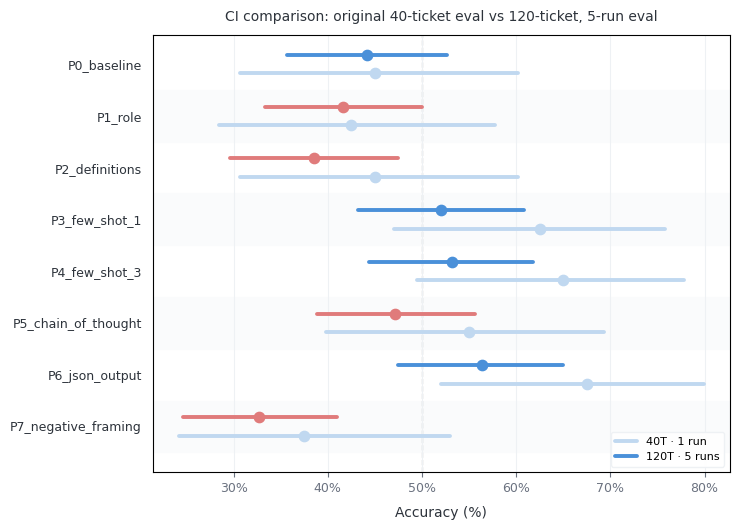

In [8]:
# Reshape to {prompt: array of shape (120 tickets, 5 runs)}
scores_mr = {
    p: (
        df_mr[df_mr["prompt_id"] == p]
        .pivot(index="input_id", columns="run_idx", values="correct")
        .values.tolist()
    )
    for p in PROMPTS
}
report_mr = pstats.compare_prompts(
    scores_mr,
    correction="holm",
    rng=np.random.default_rng(42),
)

# 120-ticket single-run report (run 1 only) for a clean three-way comparison
df_1run = df_mr[df_mr["run_idx"] == 1]
scores_1run = {p: df_1run[df_1run["prompt_id"] == p]["correct"].tolist() for p in PROMPTS}
report_1run = pstats.compare_prompts(
    scores_1run,
    correction="holm",
    rng=np.random.default_rng(42),
)

# Three-way CI width table: original 40T/1R  ->  120T/1R  ->  120T/5R
header = f"{'Prompt':<28}  {'40T · 1R':<10}  {'120T · 1R':<11}  {'120T · 5R':<11}  {'Δ tickets':<12}  {'Δ runs'}"
print(header)
print("-" * len(header))
for p in PROMPTS:
    s0 = report.model_stats[p]        # original 40-ticket eval (cell 5)
    s1 = report_1run.model_stats[p]
    s5 = report_mr.model_stats[p]
    w0 = s0.ci_high - s0.ci_low
    w1 = s1.ci_high - s1.ci_low
    w5 = s5.ci_high - s5.ci_low
    print(f"{p:<28}  {w0:>9.1%}  {w1:>10.1%}  {w5:>10.1%}  {w1 - w0:>+11.1%}  {w5 - w1:>+7.1%}")

# Forest plot: 40T single-run (light) vs 120T 5-run (coloured by tier)
pstats.plot_ci_forest(
    report_mr,
    compare_to=report,
    report_label="120T · 5 runs",
    compare_label="40T · 1 run",
    title="CI comparison: original 40-ticket eval vs 120-ticket, 5-run eval",
    sort_by="input_order"
)
plt.show()

Notice how much tighter the dark intervals are in the plot: those are the **120-ticket, 5-run** CIs, compared against the lighter **original 40-ticket** CIs for the same prompts.

The main effect is from more (and harder) eval items. Extra runs help a little (if we plotted this, we would see), but the CI tightening here is dominated by expanding the eval set. This is actually a lessen for us: _if we had to choose between getting more samples on the same items, versus expanding our eval set, we should do the latter every time._ (Of course, the latter requires much more effort on our part!)

Also notice that our original CI estimates for `P6_json_output`, `P3_few_shot_1`, etc., were over-confident. Or were they? 

When we expanded our test set with harder examples, performance flattened a bit across the board. Still, though, the JSON output prompt seems to lead. Let's output a full summary to check which are the likely winners.

In [9]:
report_mr.full_summary(pairwise_sort="significance")

Shape: BenchmarkShape(models=1, prompts=8, input_vars=1, evaluators=1, runs=5)
Templates: 8 | Inputs: 120 | Runs: 5

--- Robustness ---
                         mean  median       std        cv  iqr  cvar_10  p10  p25  p50  p75  p90
template                                                                                        
P0_baseline          0.441667     0.2  0.476610  1.079116  1.0      0.0  0.0  0.0  0.2  1.0  1.0
P1_role              0.416667     0.0  0.463515  1.112435  1.0      0.0  0.0  0.0  0.0  1.0  1.0
P2_definitions       0.385000     0.0  0.487258  1.265605  1.0      0.0  0.0  0.0  0.0  1.0  1.0
P3_few_shot_1        0.520000     1.0  0.499681  0.960924  1.0      0.0  0.0  0.0  1.0  1.0  1.0
P4_few_shot_3        0.531667     1.0  0.492291  0.925939  1.0      0.0  0.0  0.0  1.0  1.0  1.0
P5_chain_of_thought  0.471667     0.2  0.478651  1.014807  1.0      0.0  0.0  0.0  0.2  1.0  1.0
P6_json_output       0.563333     1.0  0.493305  0.875690  1.0      0.0  0.0  0.0  1.0  

This output a lot of information, but the key thing we want to look at now is the Executive Summary. We estimate three "tiers" of prompts based on which simultaneous pairwise CIs exclude zero. For `P6_json_output`, the simultaneous 95% CI on its pairwise difference versus each of P1, P2, P5, and P7 excludes zero — meaning we can conclude, at this stage, that P6 is better than those four. The top-tier prompts, by contrast, are not yet distinguishable from each other: their pairwise difference CIs all straddle zero. 

Once again, we can see the rank band info with a critical difference plot, too:

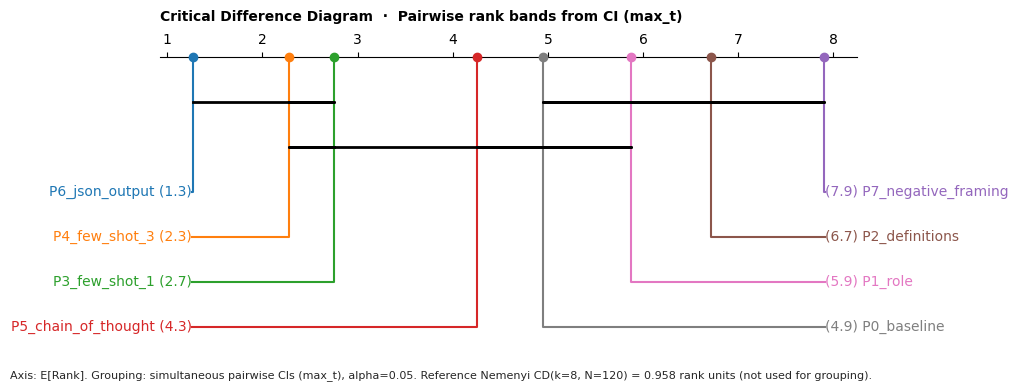

In [10]:
pstats.plot_critical_difference(report_mr)
plt.show()

If this were a real scenario, at this stage, we might drop the worst-performing candidates like P1, P2, P7, and P0, and then proceed to mutate and improve the best-performing candidates. That's the idea at the heart of evolutionary algorithms like EvoPrompt and PromptBreeder. We might also add a reflection pass, where an LLM looks at the misclassifications, identifies common failure modes, and tries to add criteria to the prompts to avoid the problems that it observed. But that's for another set of investigations.

## Conclusion: What actually moved the needle

The 76% false-positive risk from the opening wasn't a quirk of this small dataset — it's the baseline condition whenever you compare multiple prompts at once. A bar chart with 8 bars and no correction will almost always look decisive. The simultaneous CIs made the actual state of knowledge visible: at N=40, only confirmed losers could be identified; resolving the top tier required more data.

The three-way CI width table and the 40T-vs-120T·5R forest plot tell the same story about *how* to get that data:

* **Expanding the eval set led to the biggest improvement.** Going from 40 to 120 tickets cut CI widths by roughly 10–13 percentage points per prompt. The harder boundary and adversarial examples do double duty: they add statistical power *and* they stress-test prompts in the regime where real differences show up. Easy examples inflate apparent accuracy and can make weak prompts look better than they are.

* **Multiple runs weren't the bottleneck here.** The model was highly stable run-to-run (std ≈ 0–2%), so adding 4 extra runs trimmed only ~1 pp off most CIs. This isn't always the case — for generative tasks or higher-variance models, run-to-run noise is the main bottleneck and more repetitions pay off more. **The right order is: check variance first.** If per-prompt std is low, spend your budget on eval coverage; if it's high, add runs before expanding tickets.

**The general workflow this demonstrates:**

1. **Quick scan at modest N.** Don't try to pick a winner right away — use confidence intervals to instead *eliminate confirmed losers*. At N=40, P1, P2, and P7 were already separable from the top with 95% CIs, even while the top tier remained unresolved. Drop the confirmed losers and save on cost.
2. **Harden before scaling.** When you expand, composition matters as much as count. Boundary and adversarial cases reveal differences that homogeneous examples mask, and they're the inputs where prompt design decisions actually matter.
3. **Repeat until leaders separate.** At 120T/5R, a three-tier structure emerged. The conclusion here is _not_ "P6 wins" — it's "drop the bottom tier; treat P6, P4, P3 as co-leaders for the next iteration." This is the decision the statistics actually support. If we expand our eval set to more representative cases, we might actually see this relative ranking flip.

**What simultaneous CIs license:** two decisions — *eliminate* confirmed underperformers, and *withhold judgment* on the rest until you have enough data. They don't support early crowning of a winner, at least here. `P6_json_output` at 67.5% looked like a runaway lead on 40 tickets; by 120 tickets it was still ahead, but the picture was both clearer and more humbling. That's not a failure of the method — that's it working correctly.